In [2]:
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import root_mean_squared_error

In [13]:
url="https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv"

In [15]:
df=pd.read_csv(url, parse_dates=["Month"], index_col="Month")

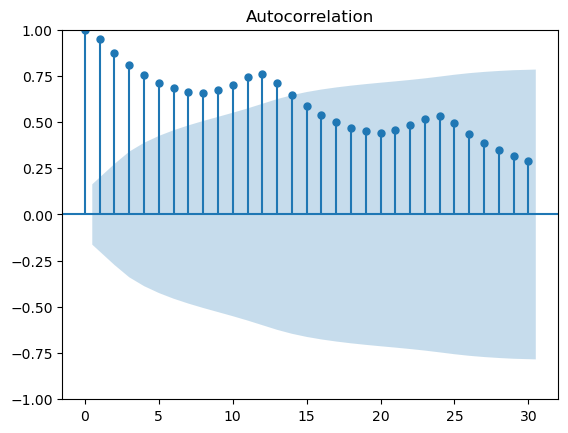

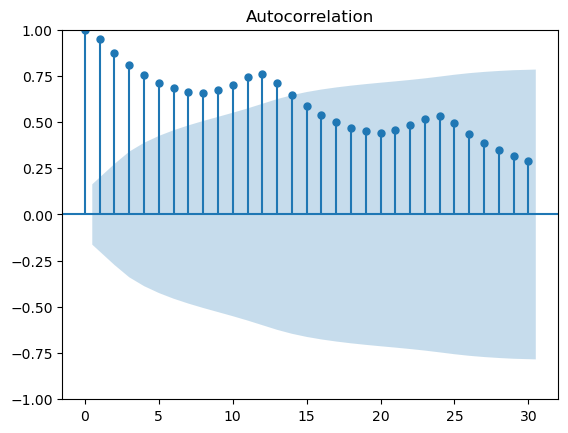

In [17]:
plot_acf(df["Passengers"],lags=30)

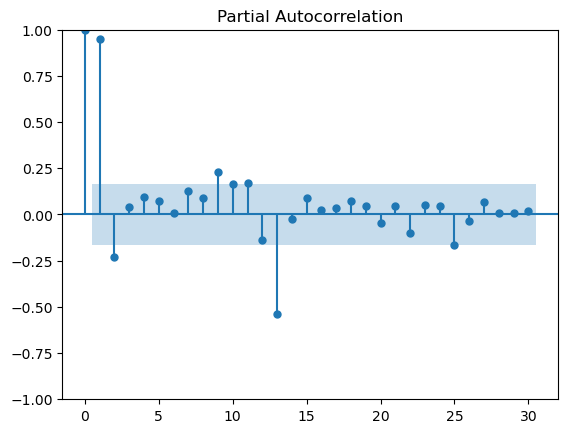

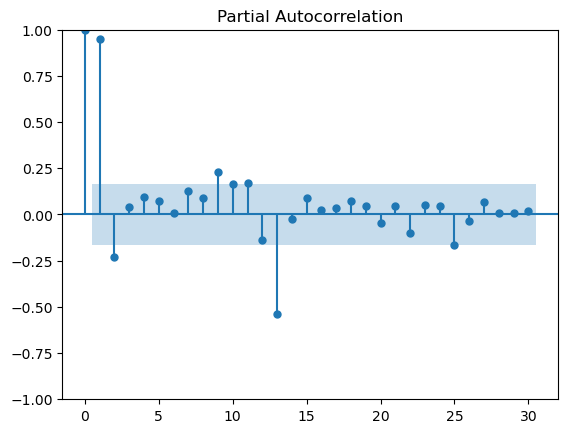

In [18]:
plot_pacf(df["Passengers"],lags=30)

In [ ]:
train_size=int(len(df)*0.8)
train,test=df[:train_size],df[train_size:]
model= ARIMA(train["Passengers"],order=(2,1,2))
model_fit=model.fit()


C:\Users\ahmed\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ahmed\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)
C:\Users\ahmed\anaconda3\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [23]:
forecast= model_fit.forecast(steps=len(test))
forecast=pd.Series(forecast,index=test.index)

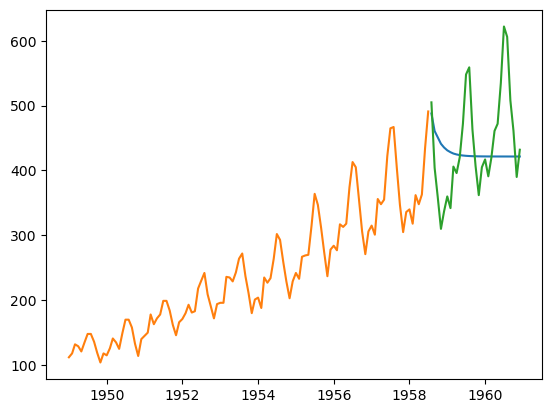

In [27]:
plt.figure()
plt.plot(forecast)
plt.plot(train)
plt.plot(test)
plt.show()